# Исследовательский анализ рынка общественного питания Москвы


### Цели и задачи проекта


*Цель проекта* - провести исследовательский анализ рынка Москвы для помощи инвесторам в выборе подходящего места для открытия заведения общественного питания (кафе, ресторана или бара) и формирования меню и цен. 

### Описание данных



Файл /datasets/rest_info.csv содержит информацию о заведениях общественного питания:
- name — название заведения;
- address — адрес заведения;
- district — административный район, в котором находится заведение, например Центральный административный округ;
- category — категория заведения, например «кафе», «пиццерия» или «кофейня»;
- hours — информация о днях и часах работы;
- rating — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
- chain — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):
  - 0 — заведение не является сетевым;
  - 1 — заведение является сетевым.
- seats — количество посадочных мест.

Файл /datasets/rest_price.csv содержит информацию о среднем чеке в заведениях общественного питания:
- price — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;
- avg_bill — хранит среднюю стоимость заказа в виде диапазона, например:
  - «Средний счёт: 1000–1500 ₽»;
  - «Цена чашки капучино: 130–220 ₽»;
  - «Цена бокала пива: 400–600 ₽».
    и так далее;
- middle_avg_bill — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»:
  - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
  - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
  - Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.
- middle_coffee_cup — число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Цена одной чашки капучино»:
  - Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
  - Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
  - Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.

### Содержимое проекта



1. Загрузка данных и знакомство с ними
2. Предобработка данных
3. Исследовательский анализ данных
4. Итоговый вывод и рекомендации
---

## 1. Загрузка данных и знакомство с ними


In [1]:
# Импортируем библиотеку
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

!pip install phik

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix

In [2]:
# Выгружаем данные в переменные bank_df и clients_df
info_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
price_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

In [3]:
info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


In [4]:
info_df.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [5]:
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


In [6]:
price_df.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


---

### Промежуточный вывод



**rest_info.csv:**
- В датасете *rest_info.csv* 9 столбцов и 8406 строк.
- Значения в столбцах соответствуют своему описанию.
- Все названия столбцов приведены к единому стилю.
- Типы данных представлены object, float64 и int64.
- Можно оптимизировать целочисленный тип данных столбца chain.
- Пропуски присутствуют в двух столбцах (hours и seats).

**rest_price.csv:**
- В датасете *rest_price.csv* 5 столбцов и 4058 строк.
- Значения в столбцах соответствуют своему описанию.
- Все названия столбцов приведены к единому стилю.
- Типы данных представлены object и float64.
- Для столбца price тип данных можно перевести в category.
- Пропуски присутствуют в четырех столбцах (price, avg_bill, middle_avg_bill и middle_coffee_cup).

### Подготовка единого датафрейма


In [7]:
df = pd.merge(info_df, price_df, on='id', how='left')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


## 2. Предобработка данных


In [10]:
#Оптимизируем целочисленный тип данных столбца seats
df['seats'] = pd.to_numeric(df['seats'], errors='coerce', downcast='integer')

In [11]:
#Оптимизируем целочисленный тип данных столбца chain
df['chain'] = pd.to_numeric(df['chain'], errors='coerce', downcast='integer')

In [12]:
#Меняем тип данных столбца price на category
df['price'] = df['price'].astype('category')

In [13]:
#Выведем новый тип данных
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   id                 8406 non-null   object  
 1   name               8406 non-null   object  
 2   category           8406 non-null   object  
 3   address            8406 non-null   object  
 4   district           8406 non-null   object  
 5   hours              7870 non-null   object  
 6   rating             8406 non-null   float64 
 7   chain              8406 non-null   int8    
 8   seats              4795 non-null   float64 
 9   price              3315 non-null   category
 10  avg_bill           3816 non-null   object  
 11  middle_avg_bill    3149 non-null   float64 
 12  middle_coffee_cup  535 non-null    float64 
dtypes: category(1), float64(4), int8(1), object(7)
memory usage: 804.7+ KB


In [14]:
#Кол-во пропущенных строк в датафрейме
df.isna().sum()

id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

In [15]:
#Процент пропущенных строк
df.isna().sum() / len(df) * 100

id                    0.000000
name                  0.000000
category              0.000000
address               0.000000
district              0.000000
hours                 6.376398
rating                0.000000
chain                 0.000000
seats                42.957411
price                60.563883
avg_bill             54.603854
middle_avg_bill      62.538663
middle_coffee_cup    93.635498
dtype: float64

Данные пропущены в 6 столбцах ('hours', 'seats', 'price', 'avg_bill', 'middle_avg_bill', 'middle_coffee_cup')
- Максимальное значение пропущенных данных в столбце 'middle_coffee_cup' - 93,6%, на втором месте столбец 'middle_avg_bill' - 62,5%, на третем месте столбец 'price' - 60,5%
- Пропуски в вышеуказанных столбцах не критичны для нашего исследовательского анализа, поэтому их можно игнорировать.

In [17]:
#Проверка явных дубликатов до нормализации данных
df.duplicated().sum()

0

In [18]:
df.duplicated(subset=['name', 'address']).sum()

0

In [19]:
#Нормализация данных в столбце 'name' с названием заведения
#df['name'] = df['name'].str.lower().str.replace(' ','_')
df['name'] = df['name'].str.lower().str.strip()
df['address'] = df['address'].str.lower().str.strip()

In [20]:
#Явные дубликаты в столбце 'name' и 'address'
df.duplicated(subset=['name', 'address'], keep='first')

0       False
1       False
2       False
3       False
4       False
        ...  
8401    False
8402    False
8403    False
8404    False
8405    False
Length: 8406, dtype: bool

In [21]:
#Выведем явные дубликаты
df[df[['name', 'address']].duplicated() == True]

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
215,897ddbc6746c4388b19dc8a9fcdbb488,кафе,кафе,"москва, парк ангарские пруды",Северный административный округ,"ежедневно, 10:00–22:00",3.2,0,NaN,NaN,NaN,NaN,NaN
1511,a69f018d5c064873a3b491b0121bc1b4,more poke,ресторан,"москва, волоколамское шоссе, 11, стр. 2",Северный административный округ,"пн-чт 09:00–18:00; пт,сб 09:00–21:00; вс 09:00...",4.2,1,188.0,NaN,NaN,NaN,NaN
2420,aba1de7ad7d64ac0a3f8684bda29d905,раковарня клешни и хвосты,"бар,паб","москва, проспект мира, 118",Северо-Восточный административный округ,"пн-чт 12:00–00:00; пт,сб 12:00–01:00; вс 12:00...",4.4,1,150.0,NaN,NaN,NaN,NaN
3109,d3116844e4e048f99614eb30be3214e0,хлеб да выпечка,кафе,"москва, ярцевская улица, 19",Западный административный округ,NaN,4.1,0,276.0,NaN,NaN,NaN,NaN


In [22]:
#Кол-во дубликатов
df.duplicated(subset=['name', 'address'], keep='first').sum()

4

In [23]:
#Удаляем явные дубликаты
df = df.drop_duplicates(subset=['name', 'address'], keep='first')

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8402 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   id                 8402 non-null   object  
 1   name               8402 non-null   object  
 2   category           8402 non-null   object  
 3   address            8402 non-null   object  
 4   district           8402 non-null   object  
 5   hours              7867 non-null   object  
 6   rating             8402 non-null   float64 
 7   chain              8402 non-null   int8    
 8   seats              4792 non-null   float64 
 9   price              3315 non-null   category
 10  avg_bill           3816 non-null   object  
 11  middle_avg_bill    3149 non-null   float64 
 12  middle_coffee_cup  535 non-null    float64 
dtypes: category(1), float64(4), int8(1), object(7)
memory usage: 804.3+ KB


- Создаем столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [25]:
df['is_24_7'] = False
df.loc[(df['hours'].str.contains('ежедневно',na=False) & df['hours'].str.contains('круглосуточно',na=False)),'is_24_7'] = True

In [26]:
# Комментарий ревьюера
df['is_24_7'].value_counts()

False    7672
True      730
Name: is_24_7, dtype: int64

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8402 entries, 0 to 8405
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   id                 8402 non-null   object  
 1   name               8402 non-null   object  
 2   category           8402 non-null   object  
 3   address            8402 non-null   object  
 4   district           8402 non-null   object  
 5   hours              7867 non-null   object  
 6   rating             8402 non-null   float64 
 7   chain              8402 non-null   int8    
 8   seats              4792 non-null   float64 
 9   price              3315 non-null   category
 10  avg_bill           3816 non-null   object  
 11  middle_avg_bill    3149 non-null   float64 
 12  middle_coffee_cup  535 non-null    float64 
 13  is_24_7            8402 non-null   bool    
dtypes: bool(1), category(1), float64(4), int8(1), object(7)
memory usage: 812.5+ KB


---

### Промежуточный вывод



Были загружены и объеденены данные из 2х датасетов /datasets/rest_info.csv и /datasets/rest_price.csv. 
Объендененный датасет содержит 13 столбцов и 8406 строк, в которых представлена информация о заведениях общественного питания и о среднем чеке в данных заведениях.

- В шести стобцах (hours, seats, price, avg_bill, middle_avg_bill и middle_coffee_cup) были обнаружены пропущенные значения.
- Максимальное значение пропущенных данных в столбце 'middle_coffee_cup' - 93,6%, на втором месте столбец 'middle_avg_bill' - 62,5%, на третем месте столбец 'price' - 60,5%.
- Для оптимизации работы с данными в датафрейме были произведены следующие изменения типов данных:
  - 'chain': тип данных изменён с int64 на int8.
  - 'price': тип данных изменён с object на category.
- Проведена нормализация данных с текстовыми значениями с целью исключения неявных дубликатов, а также выявлено 4 явных дубликата.
- После удаления явных дубликатов осталось 8402 строк.
- Создан столбец is_24_7 с обозначением того, что заведение работает ежедневно и круглосуточно.

## 3. Исследовательский анализ данных


---

### Задача 1

Какие категории заведений представлены в данных? Исследуйте количество объектов общественного питания по каждой категории. Результат сопроводите подходящей визуализацией.

In [29]:
#Количество заведений общественного питания в абсолютных значениях
df['category'].value_counts()

кафе               2376
ресторан           2042
кофейня            1413
бар,паб             764
пиццерия            633
быстрое питание     603
столовая            315
булочная            256
Name: category, dtype: int64

In [30]:
#Количества заведений общественного питания в относительных значениях
df['category'].value_counts(normalize=True)

кафе               0.282790
ресторан           0.243037
кофейня            0.168174
бар,паб            0.090931
пиццерия           0.075339
быстрое питание    0.071769
столовая           0.037491
булочная           0.030469
Name: category, dtype: float64

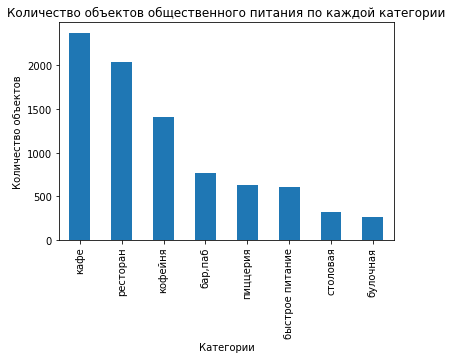

In [31]:
df['category'].value_counts().plot(kind='bar',
                title='Количество объектов общественного питания по каждой категории',
                legend=False,
                ylabel='Количество объектов',
                xlabel='Категории',
                rot=90)

plt.show()

- Больше всего заведений представлены в категории кафе, на втором месте - ресторан, на третем месте - кофейня
- Доля кафе среди всех категорий составляет 28%, доля ресторанов - 24%, доля кофеен - 17%
- Меньше всего заведений в категориях столовая и булочная, доля которых составляет 4% и 3% соответственно. 

---

### Задача 2

Какие административные районы Москвы присутствуют в данных? Исследуйте распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. Результат сопроводите подходящими визуализациями.

In [32]:
#Количество заведений по административным районам в абсолютных значениях
df['district'].value_counts()

Центральный административный округ         2242
Северный административный округ             898
Южный административный округ                892
Северо-Восточный административный округ     890
Западный административный округ             850
Восточный административный округ            798
Юго-Восточный административный округ        714
Юго-Западный административный округ         709
Северо-Западный административный округ      409
Name: district, dtype: int64

In [33]:
#Количество заведений по административным районам в относительных значениях
df['district'].value_counts(normalize=True)

Центральный административный округ         0.266841
Северный административный округ            0.106879
Южный административный округ               0.106165
Северо-Восточный административный округ    0.105927
Западный административный округ            0.101166
Восточный административный округ           0.094977
Юго-Восточный административный округ       0.084980
Юго-Западный административный округ        0.084385
Северо-Западный административный округ     0.048679
Name: district, dtype: float64

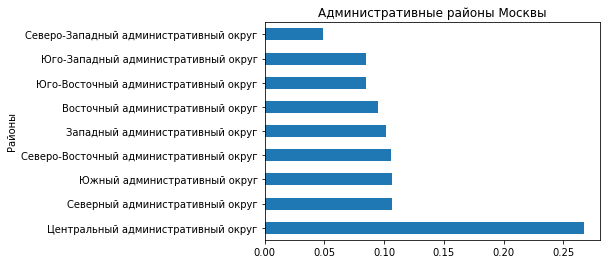

In [34]:
#Районы Москвы
df['district'].value_counts(normalize=True).plot(kind='barh',
                title='Административные районы Москвы',
                legend=False,
                ylabel='Количество заведений',
                xlabel='Районы',
                rot=0)

plt.show()

In [35]:
#Количество заведений по категориям в ЦАО в абсолютных значениях
df.groupby('district')['category'].value_counts()

district                          category       
Восточный административный округ  кафе               272
                                  ресторан           160
                                  кофейня            105
                                  пиццерия            72
                                  быстрое питание     71
                                                    ... 
Южный административный округ      быстрое питание     85
                                  пиццерия            73
                                  бар,паб             68
                                  столовая            44
                                  булочная            25
Name: category, Length: 72, dtype: int64

In [36]:
#Количество заведений по категориям в ЦАО в относительных значениях
df.groupby('district')['category'].value_counts(normalize=True)

district                          category       
Восточный административный округ  кафе               0.340852
                                  ресторан           0.200501
                                  кофейня            0.131579
                                  пиццерия           0.090226
                                  быстрое питание    0.088972
                                                       ...   
Южный административный округ      быстрое питание    0.095291
                                  пиццерия           0.081839
                                  бар,паб            0.076233
                                  столовая           0.049327
                                  булочная           0.028027
Name: category, Length: 72, dtype: float64

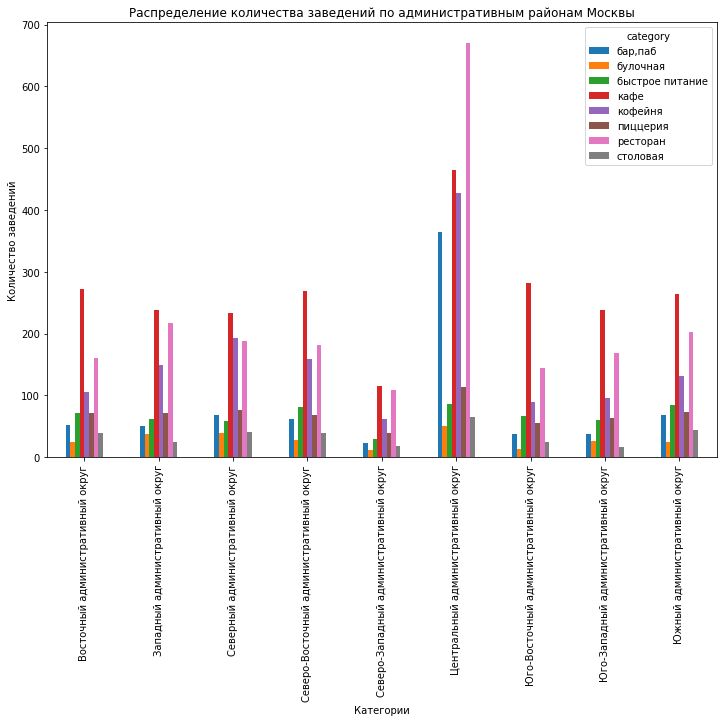

In [37]:
#Распределение количества заведений по административным районам Москвы
df_distr = df.groupby('district')['category'].value_counts().unstack(fill_value=0)

df_distr.plot(kind='bar',
                title='Распределение количества заведений по административным районам Москвы',
                legend=True,
                ylabel='Количество заведений',
                xlabel='Категории',
                rot=90, 
                figsize=(12, 8))

plt.show()

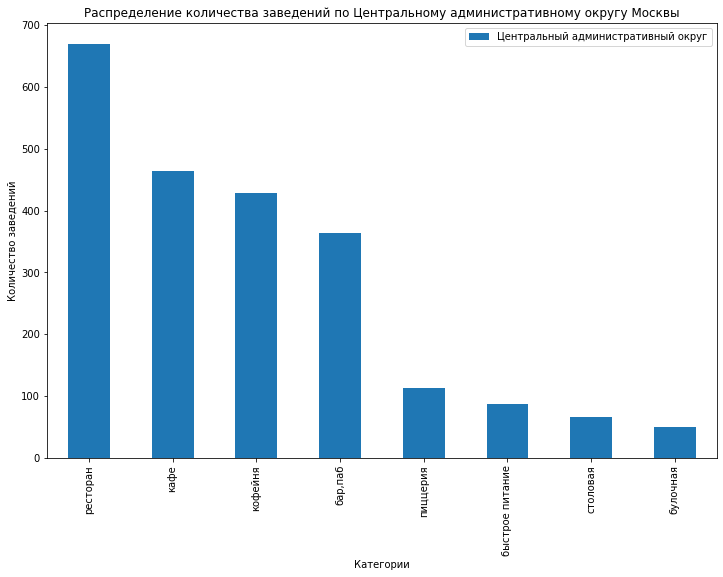

In [38]:
#Распределение заведений каждой категории в Центральном административном округе Москвы
df_distr = df.groupby('district')['category'].value_counts().unstack(fill_value=0)
centr_df = df_distr.loc['Центральный административный округ'].sort_values(ascending=False)

centr_df.plot(kind='bar',
                title='Распределение количества заведений по Центральному административному округу Москвы',
                legend=True,
                ylabel='Количество заведений',
                xlabel='Категории',
                rot=90, 
                figsize=(12, 8))

plt.show()

- Большая доля заведений находится в Центральном районе Москвы и составляет 27%.
- Самое маленькое кол-во заведений находится в Северно-Западном районе Москвы (доля заведений 5%) 
- В центральном районе топ-3 категории заведений: ресторан, кафе, кофейня. 
- Самые низкие позиции по кол-ву заведений в центральном районе занимают: булочная, столовая, быстрое питание и пиццерия. 

---

### Задача 3

Изучите соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Каких заведений больше — сетевых или несетевых? Какие категории заведений чаще являются сетевыми? Исследуйте данные, ответьте на вопросы и постройте необходимые визуализации.

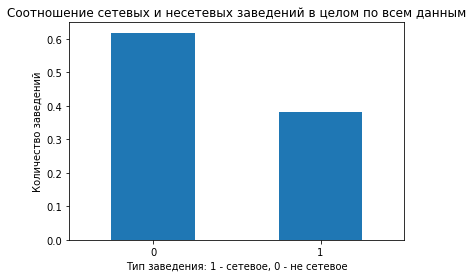

In [39]:
#Соотношение сетевых и несетевых заведений в целом по всем данным
df['chain'].value_counts(normalize=True).plot(kind='bar',
                title='Соотношение сетевых и несетевых заведений в целом по всем данным',
                legend=False,
                ylabel='Количество заведений',
                xlabel='Тип заведения: 1 - сетевое, 0 - не сетевое',
                rot=0)
plt.show()

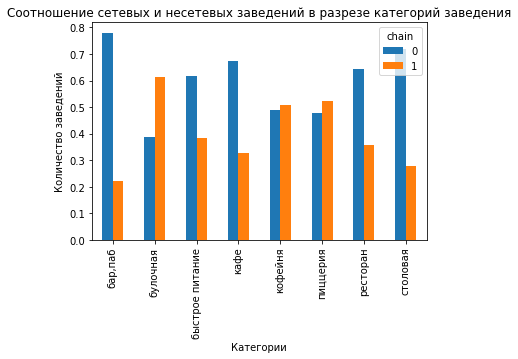

In [40]:
#Соотношение сетевых и несетевых заведений в разрезе категорий заведения
df_unstack = df.groupby('category')['chain'].value_counts(normalize=True).unstack(fill_value=0)

df_unstack.plot(kind='bar',
                title='Соотношение сетевых и несетевых заведений в разрезе категорий заведения',
                legend=True,
                ylabel='Количество заведений',
                xlabel='Категории',
                rot=90)

plt.show()

In [41]:
df_share = df.groupby('category')['chain'].mean().sort_values(ascending=False)
print(df_share)

category
булочная           0.613281
пиццерия           0.521327
кофейня            0.509554
быстрое питание    0.384743
ресторан           0.357003
кафе               0.327862
столовая           0.279365
бар,паб            0.219895
Name: chain, dtype: float64


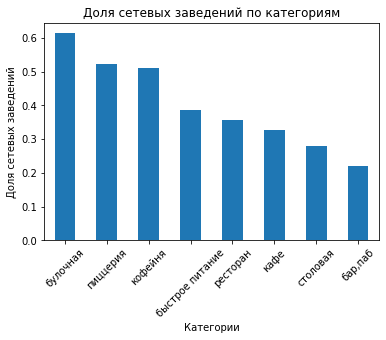

In [42]:
#Доля сетевых заведений по категориям
df_share = df.groupby('category')['chain'].mean().sort_values(ascending=False)

df_share.plot(
    kind='bar',
    title='Доля сетевых заведений по категориям',
    ylabel='Доля сетевых заведений',
    xlabel='Категории',
    rot=45
)

plt.show()

- В разрезе всех данных по количеству больше несетевых заведений, чем сетевых
- Категории заведений, которые чаще являются сетевыми: булочная (доля - 61%), пиццерия (доля - 52%), кофейня (доля - 51%)

---

### Задача 4

Исследуйте количество посадочных мест в заведениях. Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Приведите для каждой категории заведений наиболее типичное для него количество посадочных мест. Результат сопроводите подходящими визуализациями.


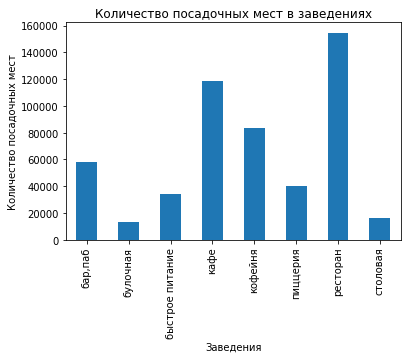

In [43]:
#Количество посадочных мест в заведениях
category_seats = df.groupby('category')['seats'].sum().plot(kind='bar',
                title='Количество посадочных мест в заведениях',
                legend=False,
                ylabel='Количество посадочных мест',
                xlabel='Заведения',
                rot=90)

In [44]:
#Статистические показатели столбца seats
df['seats'].describe()

count    4792.000000
mean      108.361436
std       122.841130
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

- Среднее значение 108.36 и медиана 75.0 находятся достаточно далеко друг от друга, что указывает на несимметричное распределение данных и наличие выраженных выбросов
- Минимальное кол-во метс - 0. Данные выбросы могут быть связаны с отсутствием внесенных данных, а также с небольшими несетевыми заведениями на небольшое кол-во мест. 
- Максимальное кол-во мест - 1288, что может быть связано с единичными большими заведениями, фуд-кортами, заведениями питания в спортивно-концертных комплексах, либо с неправильно заполненной информацией о кол-ве мест, что также является выбросами. 
- Значения меньшя 25го процентиля (40) и выше 75го процентиля (140) - можно считать выбросами. 

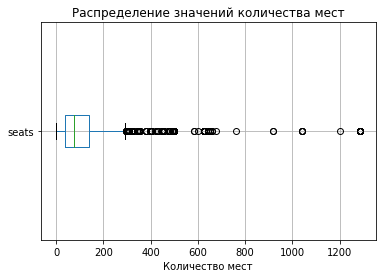

In [45]:
#Проиллюстрируем выбросы
df.boxplot(column='seats', vert=False)
plt.title('Распределение значений количества мест')
plt.xlabel('Количество мест')

plt.show() 

- Распределение кол-ва мест асимметричное, скошенное вправо. 

In [46]:
#Типичное количество посадочных мест для каждой категории заведений
median_category = df.groupby('category')['seats'].median().sort_values(ascending=False)

print(median_category)

category
ресторан           86.0
бар,паб            82.0
кофейня            80.0
столовая           75.5
быстрое питание    65.0
кафе               60.0
пиццерия           55.0
булочная           50.0
Name: seats, dtype: float64


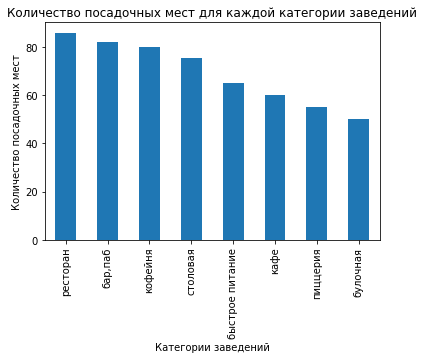

In [47]:
median_category = df.groupby('category')['seats'].median().sort_values(ascending=False).plot(kind='bar',
                title='Количество посадочных мест для каждой категории заведений',
                legend=False,
                ylabel='Количество посадочных мест',
                xlabel='Категории заведений',
                rot=90)

- Больше всего посадочных мест в категории рестораны, бар/паб, кофейня, меньше всего в категории булочная. 

---

### Задача 5

Исследуйте рейтинг заведений. Визуализируйте распределение средних рейтингов по категориям заведений. Сильно ли различаются усреднённые рейтинги для разных типов общепита?

In [48]:
print(df['rating'].describe())

count    8402.000000
mean        4.230017
std         0.470320
min         1.000000
25%         4.100000
50%         4.300000
75%         4.400000
max         5.000000
Name: rating, dtype: float64


In [49]:
print(df.groupby('category')['rating'].describe())

                  count      mean       std  min  25%  50%  75%  max
category                                                            
бар,паб           764.0  4.387696  0.380392  1.1  4.3  4.4  4.6  5.0
булочная          256.0  4.268359  0.386303  1.3  4.2  4.3  4.4  5.0
быстрое питание   603.0  4.050249  0.560949  1.1  3.9  4.2  4.3  5.0
кафе             2376.0  4.124285  0.566001  1.0  4.0  4.2  4.4  5.0
кофейня          1413.0  4.277282  0.372250  1.4  4.1  4.3  4.4  5.0
пиццерия          633.0  4.301264  0.336162  1.0  4.2  4.3  4.4  5.0
ресторан         2042.0  4.290402  0.413143  1.0  4.2  4.3  4.5  5.0
столовая          315.0  4.211429  0.454205  1.0  4.1  4.3  4.4  5.0


In [50]:
category_rating = df.groupby('category')['rating'].mean().sort_values(ascending=False)
print(category_rating)

category
бар,паб            4.387696
пиццерия           4.301264
ресторан           4.290402
кофейня            4.277282
булочная           4.268359
столовая           4.211429
кафе               4.124285
быстрое питание    4.050249
Name: rating, dtype: float64


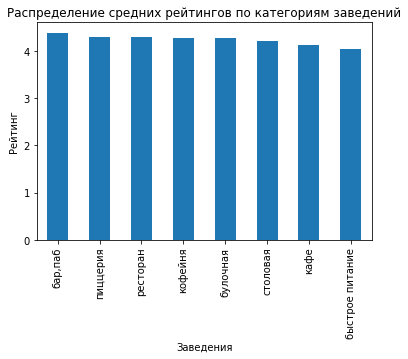

In [51]:
#Распределение средних рейтингов по категориям заведений
category_rating = df.groupby('category')['rating'].mean().sort_values(ascending=False).plot(kind='bar',
                title='Распределение средних рейтингов по категориям заведений',
                legend=False,
                ylabel='Рейтинг',
                xlabel='Заведения',
                rot=90)

- Средний рейтинг по Москве практически одинаков для всех категорий заведений и составлет 4+.
- Наивысший рейтинг у заведений в категории бар/паб (4.39), ниже всего рейтинг в категории быстрое питание (4.05)

---

### Задача 6

Изучите, с какими данными показывают самую сильную корреляцию рейтинги заведений? Постройте и визуализируйте матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберите самую сильную связь и проверьте её.

In [52]:
correlation_matrix = df[['rating', 'category', 'district', 'chain', 'seats', 'price', 'is_24_7']].phik_matrix()

correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)

interval columns not set, guessing: ['rating', 'chain', 'seats']


,rating
price,0.220295
district,0.200761
category,0.189716
is_24_7,0.150365
chain,0.107833
seats,0.000000


interval columns not set, guessing: ['rating', 'chain', 'seats']


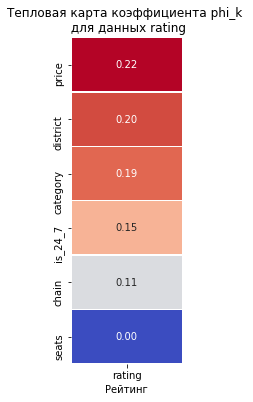

In [53]:
plt.figure(figsize=(2, 6))

correlation_matrix = df[['rating', 'category', 'district', 'chain', 'seats', 'price', 'is_24_7']].phik_matrix()

data_heatmap = correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)
sns.heatmap(data_heatmap,
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            linewidths=0.5, 
            cbar=False )

plt.title('Тепловая карта коэффициента phi_k \n для данных rating')
plt.xlabel('Рейтинг')

plt.show()

interval columns not set, guessing: ['chain', 'seats', 'rating']


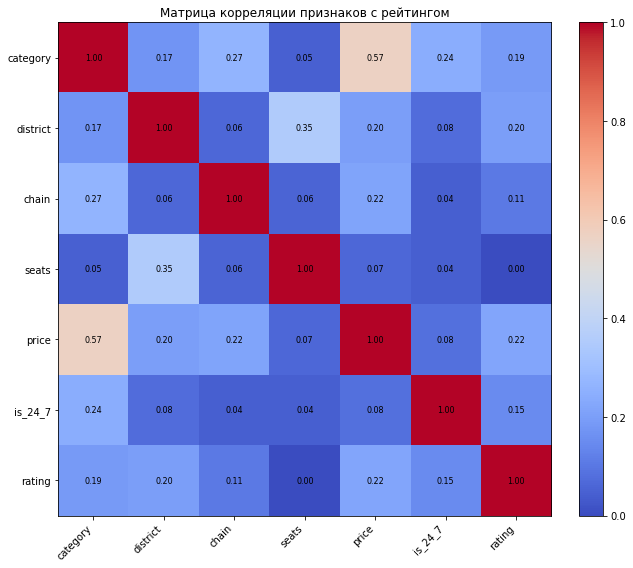

Коэффициент phi_k: 0.22


In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from phik import report
features = ['category', 'district', 'chain', 'seats', 'price', 'is_24_7', 'rating']

correlation_matrix = df[features].phik_matrix()

plt.figure(figsize=(10, 8))
im = plt.imshow(correlation_matrix.values, cmap='coolwarm', vmin=0, vmax=1)

plt.xticks(np.arange(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45, ha='right')
plt.yticks(np.arange(len(correlation_matrix.columns)), correlation_matrix.columns)

for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        value = correlation_matrix.iloc[i, j]
        plt.text(j, i, f"{value:.2f}", ha='center', va='center', color='black', fontsize=8)

plt.title("Матрица корреляции признаков с рейтингом")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

corr_with_rating = correlation_matrix['rating'].drop('rating')
strongest_feature = corr_with_rating.abs().idxmax()
strength_value = correlation_matrix.loc[strongest_feature, 'rating']

print(f"Коэффициент phi_k: {strength_value:.2f}")

- Наибольшая корреляция рейтинга наблюдается с категорией цен в заведениях (0.22), административным районом (0.20) и категорией заведений (0.19). Для остальных признаков коэффициент корреляции снижается с 0.15 до 0.
- Между категорией заведения и категорией цены самая сильная связь (0.58), что означает, что тип заведения сильно влияет на его ценовую категорию. 

In [55]:
#Расчет значения среднего рейтинга для разных ценовых категорий заведений
mean_rating = df.groupby('price')['rating'].mean()

price_order = ['низкие', 'средние', 'выше среднего', 'высокие']
mean_rating = mean_rating.reindex(price_order)

print(mean_rating)

price
низкие           4.173077
средние          4.297874
выше среднего    4.386348
высокие          4.436611
Name: rating, dtype: float64


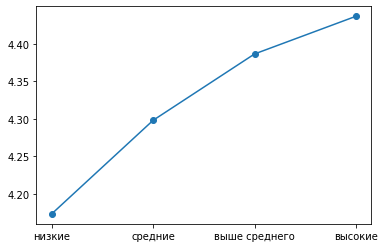

In [56]:
#Визуализация
plt.plot(mean_rating.index, mean_rating.values, marker='o')

plt.show()

- Средний рейтинг заведений увеличивается по мере роста ценовой категории.
- Самые высокие оценки получают заведения высокого ценового сегмента. Это может свидетельствовать о более высоком качестве сервиса, кухни и атмосферы в дорогих ресторанах.

---

### Задача 7

Сгруппируйте данные по названиям заведений и найдите топ-15 популярных сетей в Москве. Для них посчитайте значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе. К какой категории заведений они относятся? Результат сопроводите подходящими визуализациями.

In [57]:
#Топ-15 популярных сетей в Москве
top_15 = (df[df['chain'] == 1].groupby('name').agg(name_count=('name', 'count'), avg_rating=('rating', 'mean')).sort_values(by='name_count', ascending=False).reset_index().head(15))

print(top_15)

                                   name  name_count  avg_rating
0                           шоколадница         120    4.177500
1                        домино'с пицца          76    4.169737
2                            додо пицца          74    4.286486
3                      one price coffee          71    4.064789
4                          яндекс лавка          69    3.872464
5                                 cofix          65    4.075385
6                                 prime          50    4.116000
7                            хинкальная          44    4.322727
8                              кофепорт          42    4.147619
9   кулинарная лавка братьев караваевых          39    4.394872
10                              теремок          38    4.123684
11                              чайхана          37    3.924324
12                             cofefest          32    3.984375
13                              буханка          32    4.396875
14                                му-му 

In [58]:
# Комментарий ревьюера 2
tmp = df.copy()          # создаем копию текущего датасета
name_tmp = 'му-му'       # задаем имя столбца для проверки уникальных категорий
print(f'Заведения с одинаковым именем {name_tmp} относятся к разным категориям:\n\
{", ".join(tmp[tmp.name == name_tmp].category.unique())}')

Заведения с одинаковым именем му-му относятся к разным категориям:
кафе, ресторан, кофейня, быстрое питание, пиццерия, столовая, бар,паб


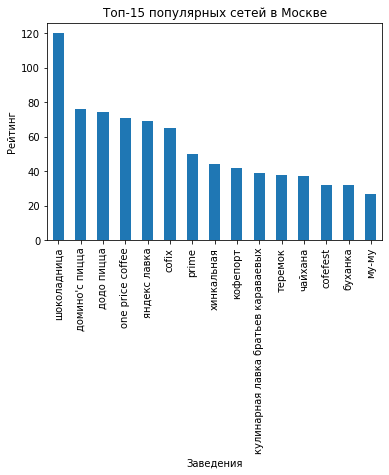

In [59]:
#график топ-15 популярных сетей в Москве
top_15.plot(kind='bar',
            x='name', y='name_count',
                title='Топ-15 популярных сетей в Москве',
                legend=False,
                ylabel='Рейтинг',
                xlabel='Заведения',
                rot=90)
plt.show()

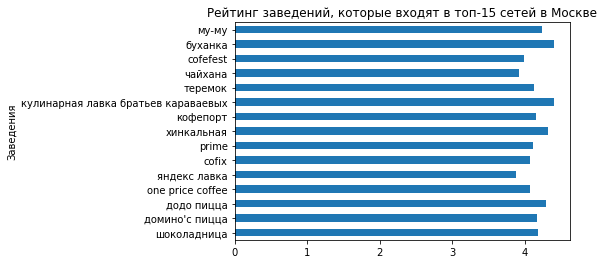

In [60]:
#Рейтинг заведений, которые входят в топ-15 сетей в Москве
top_15.plot(kind='barh',
            x='name', y='avg_rating',
                title='Рейтинг заведений, которые входят в топ-15 сетей в Москве',
                legend=False,
                ylabel='Рейтинг',
                xlabel='Заведения',
                rot=0)
plt.show()

- Самые популярные заведения в Москве - "Шоколадница" (категория кофейня) и "Домино'с_пицца" (категория пиццерия), "Додо пицца" (категория пиццерия).
- Значения рейтинга для Топ-15 заведений в Москве выше 3.9

---

### Задача 8

Изучите вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируйте цены в Центральном административном округе и других. Как удалённость от центра влияет на цены в заведениях? Результат сопроводите подходящими визуализациями.


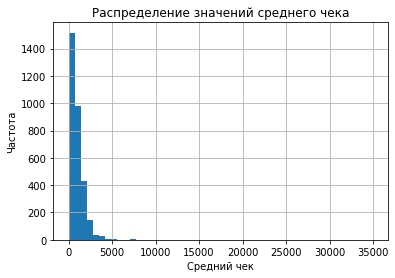

In [61]:
df['middle_avg_bill'].hist(bins=50)

plt.title('Распределение значений среднего чека')
plt.xlabel('Средний чек')
plt.ylabel('Частота')

plt.show()

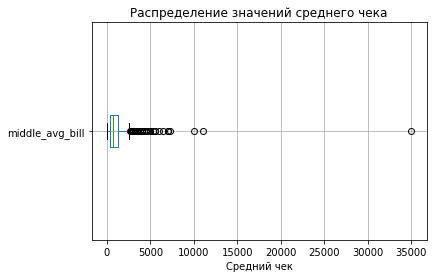

In [62]:
df.boxplot(column='middle_avg_bill', vert=False)
plt.title('Распределение значений среднего чека')
plt.xlabel('Средний чек')

plt.show()

- Распределение значений среднего чека асимметричное, скошенное вправо.

In [63]:
df['middle_avg_bill'].describe()

count     3149.000000
mean       958.053668
std       1009.732845
min          0.000000
25%        375.000000
50%        750.000000
75%       1250.000000
max      35000.000000
Name: middle_avg_bill, dtype: float64

- Среднее значение (958) и медиана (750) находятся достаточно далеко друг от друга, что указывает на несимметричное распределение данных и наличие выраженных выбросов
- Минимальный ср чек - 0. Данные выбросы могут быть связаны с отсутствием внесенных данных, а также с различными акциями, бартерным сотрудничеством.
- Максимальный ср чек - 35000, что может быть связано с единичным большим чеком в дорогостоящем ресторане, либо с неправильно заполненной информацией о ср.чеке, что также является выбросами.
- Значения меньшя 25го процентиля (375) и выше 75го процентиля (1250) - можно считать выбросами.

In [64]:
bill = df.groupby('district')['middle_avg_bill'].agg(['mean', 'median'])
print(bill)

                                                mean  median
district                                                    
Восточный административный округ          820.626923   575.0
Западный административный округ          1053.225490  1000.0
Северный административный округ           927.959627   650.0
Северо-Восточный административный округ   716.611296   500.0
Северо-Западный административный округ    822.222930   700.0
Центральный административный округ       1191.057547  1000.0
Юго-Восточный административный округ      654.097938   450.0
Юго-Западный административный округ       792.561702   600.0
Южный административный округ              834.398089   500.0


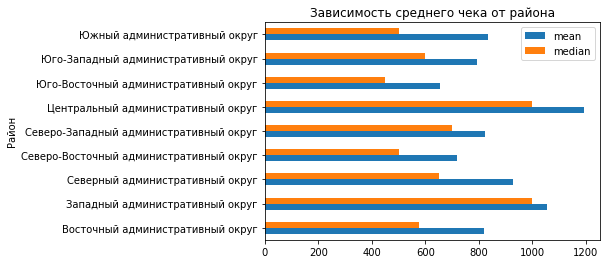

In [65]:
bill= df.groupby('district')['middle_avg_bill'].agg(['mean', 'median'])
bill.plot(kind='barh',
                title='Зависимость среднего чека от района',
                legend=True,
                ylabel='Средний чек заведения',
                xlabel='Район',
                rot=0)

plt.show()

- Самый высокий средний чек наблюдается в Центральном районе Москвы (1191.1)
- Далее чек снижается в зависимости от удаленности района:
  - В Западном, Северном и Северо-Западном районе также наблюдается высокий средний чек (1053.2, 927.9 и 822.2 соответственно)
  - Самый низкий средний чек наблюдается в Юго-Восточном (654.1), Северо-Востояном (716.6) и Юго-Западном (792.6) районах.

---

### Промежуточный вывод


- По Москве больше всего заведений представлены в категории кафе, на втором месте - ресторан, на третем месте - кофейня. Доля кафе составляет 28%, доля ресторанов - 24%, доля кофеен - 17%. Меньше всего заведений в категориях столовая и булочная, доля которых составляет 4% и 3% соответственно.
- Большая доля заведений находится в Центральном районе Москвы и составляет 27%. Самое маленькое кол-во заведений находится в Северно-Западном районе Москвы (доля заведений 5%)
- Самое маленькое кол-во заведений находится в Северно-Западном районе Москвы. 
- В центральном районе топ-3 категории заведений: ресторан, кафе, кофейня. 
- Самые низкие позиции по кол-ву заведений в центральном районе занимают: булочная, столовая, быстрое питание и пиццерия.

- В разрезе всех данных по количеству больше несетевых заведений, чем сетевых
- Категории заведений, которые чаще являются сетевыми: булочная (доля - 61%), пиццерия (доля - 52%), кофейня (доля - 51%)
  
- Средний рейтинг по Москве практически одинаков для всех категорий заведений и составлет 4+
- Наивысший рейтинг у заведений в категории бар/паб (4.39), ниже всего рейтинг в категории быстрое питание (4.05)

- Наибольшая корреляция рейтинга наблюдается с категорией цен в заведениях (0.22), административным районом (0.20) и категорией заведений (0.19). Для остальных признаков коэффициент корреляции снижается с 0.15 до 0.
- Коэффициент корреляции 0.22 означает слабо-положительную связь между ценовой категорией и рейтингом. 
- Между категорией заведения и категорией цены самая сильная связь (0.58), что означает, что тип заведения сильно влияет на его ценовую категорию. 

- Выделены Топ-15 популярных сетей в Москве. 
- Самые популярные заведения в Москве - "Шоколадница" (категория кофейня) и "Домино'с_пицца" (категория пиццерия), "Додо пицца" (категория пиццерия).
- Значения рейтинга для Топ-15 заведений в Москве выше 3.9

- Самый высокий средний чек наблюдается в Центральном районе Москвы (1191.1)
- Далее чек снижается в зависимости от удаленности района:
  - В Западном, Северном и Северо-Западном районе также наблюдается высокий средний чек (1053.2, 927.9 и 822.2 соответственно)
  - Самый низкий средний чек наблюдается в Юго-Восточном (654.1), Северо-Востояном (716.6) и Юго-Западном (792.6) районах.

## 4. Итоговый вывод и рекомендации



**На этапе предобработки данных:**

Были загружены и объеденены данные из 2х датасетов /datasets/rest_info.csv и /datasets/rest_price.csv. Объендененный датасет содержит 13 столбцов и 8406 строк, в которых представлена информация о заведениях общественного питания и о среднем чеке в данных заведениях.

- В шести стобцах (hours, seats, price, avg_bill, middle_avg_bill и middle_coffee_cup) были обнаружены пропущенные значения.
- Максимальное значение пропущенных данных в столбце 'middle_coffee_cup' - 93,6%, на втором месте столбец 'middle_avg_bill' - 62,5%, на третем месте столбец 'price' - 60,5%.
- Для оптимизации работы с данными в датафрейме были произведены следующие изменения типов данных:
  - 'chain': тип данных изменён с int64 на int8.
  - 'price': тип данных изменён с object на category.
- Проведена нормализация данных с текстовыми значениями с целью исключения неявных дубликатов, а также выявлено 4 явных дубликата.
- После удаления явных дубликатов осталось 8402 строк.
- Создан столбец is_24_7 с обозначением того, что заведение работает ежедневно и круглосуточно.

**При исследовательсом анализе выявлено:**

- По Москве больше всего заведений представлены в категории кафе, на втором месте - ресторан, на третем месте - кофейня. Доля кафе составляет 28%, доля ресторанов - 24%, доля кофеен - 17%. Меньше всего заведений в категориях столовая и булочная, доля которых составляет 4% и 3% соответственно.
- Большая доля заведений находится в Центральном районе Москвы и составляет 27%. Самое маленькое кол-во заведений находится в Северно-Западном районе Москвы (доля заведений 5%)
- Самое маленькое кол-во заведений находится в Северно-Западном районе Москвы. 
- В центральном районе топ-3 категории заведений: ресторан, кафе, кофейня. 
- Самые низкие позиции по кол-ву заведений в центральном районе занимают: булочная, столовая, быстрое питание и пиццерия.

- В разрезе всех данных по количеству больше несетевых заведений, чем сетевых
- Категории заведений, которые чаще являются сетевыми: булочная (доля - 61%), пиццерия (доля - 52%), кофейня (доля - 51%)
  
- Средний рейтинг по Москве практически одинаков для всех категорий заведений и составлет 4+
- Наивысший рейтинг у заведений в категории бар/паб (4.39), ниже всего рейтинг в категории быстрое питание (4.05)

- Наибольшая корреляция рейтинга наблюдается с категорией цен в заведениях (0.22), административным районом (0.20) и категорией заведений (0.19). Для остальных признаков коэффициент корреляции снижается с 0.15 до 0.
- Коэффициент корреляции 0.22 означает слабо-положительную связь между ценовой категорией и рейтингом. 
- Между категорией заведения и категорией цены самая сильная связь (0.58), что означает, что тип заведения сильно влияет на его ценовую категорию. 

- Выделены Топ-15 популярных сетей в Москве. 
- Самые популярные заведения в Москве - "Шоколадница" (категория кофейня) и "Домино'с_пицца" (категория пиццерия), "Додо пицца" (категория пиццерия).
- Значения рейтинга для Топ-15 заведений в Москве выше 3.9

- Самый высокий средний чек наблюдается в Центральном районе Москвы (1191.1)
- Далее чек снижается в зависимости от удаленности района:
  - В Западном, Северном и Северо-Западном районе также наблюдается высокий средний чек (1053.2, 927.9 и 822.2 соответственно)
  - Самый низкий средний чек наблюдается в Юго-Восточном (654.1), Северо-Востояном (716.6) и Юго-Западном (792.6) районах.

**Рекомендации на основе анализа данных:**

- Для открытия кафе можно рассмотреть Центральный административнй окуруг, так как там самый высокий средний чек, но также и самая высокая конкуренция по количеству открытых заведений, что может негативно сказаться на бизнесе. 
- Или можно рассмотреть менее загруженный по кол-ву заведений административный округ, также с относительно высоким средним чеком (Западный, Северный или Северо-Западный административный округ).
- Можно рассмотреть открытие заведения в категории кафе или рестораны, так как они самые востребованные. 
- Для бизнеса в Москве важно будет иметь показатель рейтинга заведения больше 4, поэтому нужно сделать акцент на качестве и маркентинге. 

- Второй путь открытия бизнеса: выбрать админимстративный округ с наименьшем количеством открытых заведений, не самую перегруженную конкуренцией категорию и занять нишу своим бизнесом с акцентом на качество, маркетинг и конкурентные цены для данного округа. 